### Homework 4

#### Set up

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, roc_curve

df_raw = pd.read_csv('../00-data/course_lead_scoring_2026.csv')
df = df_raw.copy()
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [147]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [148]:
columns_categorical = ['industry', 'employment_status', 'location', 'lead_source']
columns_numeric = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [149]:
# For categorical features, replace missing values with 'NA'
for c in columns_categorical:
    df[c] = df[c].fillna('NA')
# For numeric features, replace with 0.0
for c in columns_numeric:
    df[c] = df[c].fillna(0.0)
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [150]:
# Split the data into 3 parts with these exact calls
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values
df_train = df_train.drop(columns=['converted'])
df_val = df_val.drop(columns=['converted'])
df_test = df_test.drop(columns=['converted'])

Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables. 

Let's do that

* For each numerical variable, use it as score (aka prediction) and compute the AUC with the `y` variable as ground truth.
* Use the training dataset for that


If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

In [151]:
aucs = {}
for col in columns_numeric:
    auc = roc_auc_score(y_train, df_train[col])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[col])
    aucs[col] = auc
    print(f'col: {col}: - auc: {auc:.3f}')

col: annual_income: - auc: 0.608
col: number_of_courses_viewed: - auc: 0.723
col: interaction_count: - auc: 0.765
col: lead_score: - auc: 0.788


In [152]:
print(f'Numerical variable with the highest AUC is: {max(aucs, key=aucs.get)}')

Numerical variable with the highest AUC is: lead_score


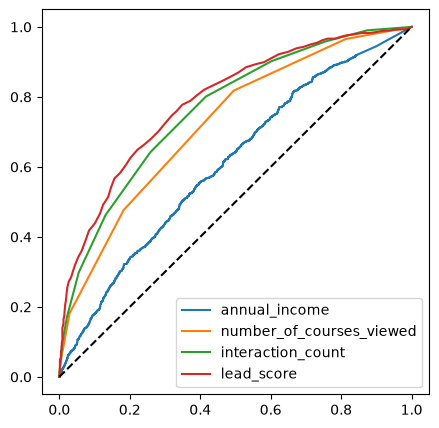

In [153]:
plt.figure(figsize=(5, 5))
for col in columns_numeric:
    fpr, tpr, _ = roc_curve(y_train, df_train[col])
    plt.plot(fpr, tpr, label=col)
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.show()

#### Question 2: Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

What's the AUC of this model on the validation dataset? (round to 3 digits)

In [154]:
# One hot encoding
dv = DictVectorizer(sparse=False)
train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)
val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

#Training
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict_proba(X_val)[:, 1]

# AUC
score = roc_auc_score(y_val, y_pred)
print(f'AUC score: {score:.3f}')


AUC score: 0.732


#### Question 3: Precision and Recall

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect? Ignore thresholds at
which both metrics are zero, and choose the threshold with the smallest
absolute difference between precision and recall.

In [155]:
results = []

for threshold in np.linspace(0.0, 1.0, 101):
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    predicted_positive = (y_pred >= threshold)
    predicted_negative = (y_pred < threshold)
    tp = (actual_positive & predicted_positive).sum()
    tn = (actual_negative & predicted_negative).sum()
    fp = (actual_negative & predicted_positive).sum()
    fn = (actual_positive & predicted_negative).sum()
    if (tp + fp) == 0:
        precision = 0.0
    else:
        precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    if precision != 0.0 or recall != 0.0:
        results.append((threshold, tp, tn, fp, fn, precision, recall))
    
results = pd.DataFrame(results, columns=['threshold', 'tp', 'tn', 'fp', 'fn', 'precision', 'recall'])

print(results)  

    threshold   tp   tn   fp   fn  precision    recall
0        0.00  586    0  414    0   0.586000  1.000000
1        0.01  586    0  414    0   0.586000  1.000000
2        0.02  586    0  414    0   0.586000  1.000000
3        0.03  586    0  414    0   0.586000  1.000000
4        0.04  586    0  414    0   0.586000  1.000000
..        ...  ...  ...  ...  ...        ...       ...
92       0.92    8  413    1  578   0.888889  0.013652
93       0.93    6  414    0  580   1.000000  0.010239
94       0.94    3  414    0  583   1.000000  0.005119
95       0.95    2  414    0  584   1.000000  0.003413
96       0.96    1  414    0  585   1.000000  0.001706

[97 rows x 7 columns]


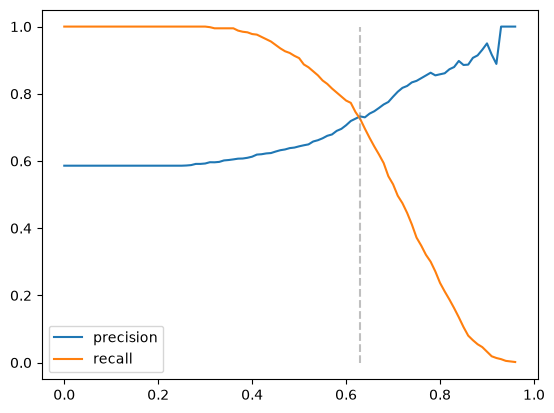

In [156]:
plt.plot(results.threshold, results.precision, label='precision')
plt.plot(results.threshold, results.recall, label='recall')
plt.vlines(0.63, 0, 1, color='grey', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [157]:
results['diff'] = (results['precision'] - results['recall']).abs()
threshold_optimal = results.loc[results['diff'].idxmin(), 'threshold']
print(f'Threshold with minimum absolute difference between precision and recall is: {threshold_optimal:.2f}')

Threshold with minimum absolute difference between precision and recall is: 0.63


#### Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

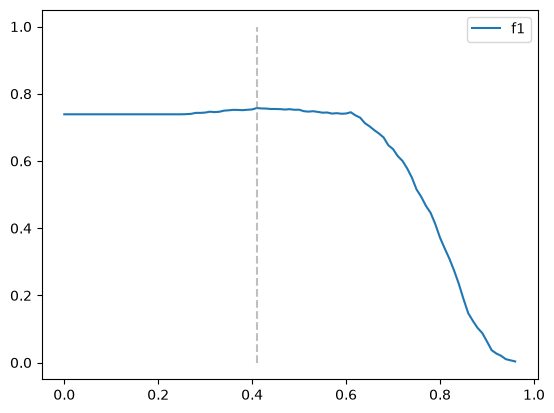

,threshold,tp,tn,fp,fn,precision,recall,diff,f1
41,0.41,572,62,352,14,0.619048,0.976109,0.357062,0.757616


In [158]:
results['f1'] = 2 * results['precision'] * results['recall'] / (results['precision'] + results['recall'])
plt.plot(results.threshold, results.f1, label='f1')
plt.vlines(0.41, 0, 1, color='grey', linestyle='--', alpha=0.5)
plt.legend()
plt.show()
results.loc[results['f1'] == results['f1'].max()]

#### Question 5: 5-Fold CV

Use the `KFold` class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```

* Iterate over different folds of `df_full_train`
* Split the data into train and validation
* Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
* Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

In [159]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[columns_categorical + columns_numeric].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    return dv, model

def predict(df, dv, model):
    dicts = df[columns_categorical + columns_numeric].to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

scores = []
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    y_train = df_train['converted'].values
    y_val = df_val['converted'].values
    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)
    score = roc_auc_score(y_val, y_pred)
    scores.append(score)
    print(f'AUC score: {score:.3f}')

print(f'Scores mean: {np.mean(scores):.3f} std: {np.std(scores):.3f}')
    


AUC score: 0.731
AUC score: 0.730
AUC score: 0.736
AUC score: 0.741
AUC score: 0.721
Scores mean: 0.732 std: 0.007


#### Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.000001, 0.001, 1]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean ROC AUC as well as the std (round the mean and std to 3
  decimal digits).

Which `C` leads to the best mean ROC AUC?

In [171]:

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
c_scores = {}
for C in [0.000001, 0.001, 1]:
    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
        y_train = df_train['converted'].values
        y_val = df_val['converted'].values
        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)
        score = roc_auc_score(y_val, y_pred)
        scores.append(score)

    print(f'C {C} Scores mean: {np.mean(scores):.3f} std: {np.std(scores):.3f}')
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    c_scores[C] = (mean_score, std_score)
best_c = max(c_scores, key=lambda k: c_scores[k][0])
best_mean_auc = c_scores[best_c][0]

print(f'The best C parameter is: {best_c} with a Mean AUC of {best_mean_auc:.3f}')


C 1e-06 Scores mean: 0.617 std: 0.019
C 0.001 Scores mean: 0.749 std: 0.010
C 1 Scores mean: 0.732 std: 0.007
The best C parameter is: 0.001 with a Mean AUC of 0.749
